In [40]:
import warnings
import sys
sys.path.append(r'work/util.py')
from util import *
warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import lit, col
from dateutil.relativedelta import relativedelta
from pyspark.sql.types import StructType, StructField, StringType, LongType
from pyspark.sql.functions import expr, col, round, avg, max, min, sum, count, when, lit
from itertools import product
from datetime import datetime
import pytz
import os
import logging

from warnings import filterwarnings
from sklearn.model_selection import TunedThresholdClassifierCV
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
# from sklearn.model_selection import TunedThresholdClassifierCV  # This import may not exist, but leaving as is for now
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, f1_score, make_scorer, accuracy_score, precision_score, recall_score, auc
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from category_encoders import TargetEncoder
from category_encoders.woe import WOEEncoder
from sklearn.feature_selection import SelectFromModel, SelectKBest, f_classif
from sklearn.metrics import make_scorer, fbeta_score
import numpy as np
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, fbeta_score
import joblib
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
import pickle

filterwarnings('ignore')

In [41]:
def configure_spark():

    spark = (
        SparkSession.builder
        .appName("lakehouse-jupyter-abt")

        # conexão com cluster
        .master(os.getenv("SPARK_MASTER"))

        # 🚨 ESSENCIAL em Docker
        .config("spark.driver.host", os.getenv("SPARK_DRIVER_HOST"))
        .config("spark.driver.bindAddress", "0.0.0.0")

        # Delta Lake
        .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
        .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")

        # S3 / MinIO
        .config("spark.hadoop.fs.s3a.endpoint", os.getenv("MINIO_ENDPOINT"))
        .config("spark.hadoop.fs.s3a.path.style.access", "true")
        .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false")

        .config("spark.hadoop.fs.s3a.access.key", os.getenv("AWS_ACCESS_KEY_ID"))
        .config("spark.hadoop.fs.s3a.secret.key", os.getenv("AWS_SECRET_ACCESS_KEY"))

        .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
        .config(
            "spark.hadoop.fs.s3a.aws.credentials.provider",
            "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider"
        )

        # performance
        .config("spark.sql.adaptive.enabled", "true")

        # Delta fix
        .config("spark.databricks.delta.retentionDurationCheck.enabled", "false")

        .getOrCreate()
    )

    spark.sparkContext.setLogLevel("WARN")

    return spark

In [42]:
spark = configure_spark()
spark

In [43]:
abt_treino_00 = spark.read.table("delta.`s3a://gold/abt_treino`")
abt_teste_00 =  spark.read.table("delta.`s3a://gold/abt_teste`")

In [44]:
abt_treino = abt_treino_00.toPandas()

In [45]:
abt_teste = abt_teste_00.toPandas()

In [46]:
spark.stop()

In [47]:
abt_treino = abt_treino.copy()
abt_treino_01 = abt_treino.drop(columns=[])
abt_treino_01.head()

,seller_id,safra,churn_flag,vl_med_u1m_qtdPedidos_pedidos,vl_max_u1m_qtdPedidos_pedidos,vl_min_u1m_qtdPedidos_pedidos,vl_med_u1m_qtdItensVendidos_pedidos,vl_max_u1m_qtdItensVendidos_pedidos,vl_min_u1m_qtdItensVendidos_pedidos,vl_med_u1m_qtdProdutosVendidos_pedidos,...,raz_med_u9m_u12m_pct_detratores_reviews,raz_med_u9m_u12m_nps_proxy_reviews,raz_med_u9m_u12m_qtd_negativas_com_atraso_reviews,raz_med_u9m_u12m_pct_negativas_com_atraso_reviews,raz_med_u9m_u12m_avg_atraso_entrega_negativas_reviews,raz_med_u9m_u12m_flag_review_media_baixa_reviews,raz_med_u9m_u12m_flag_muitos_detratores_reviews,raz_med_u9m_u12m_flag_muitos_negativos_reviews,raz_med_u9m_u12m_flag_baixa_reputacao_reviews,raz_med_u9m_u12m_flag_alta_amplitude_reviews
0,001cca7ae9ae17fb1caed9dfb1094831,201804,1,6.0,7.0,5.0,6.0,7.0,5.0,6.0,...,1.000000,0.922691,1.250000,1.200000,0.850885,1.250000,0.789474,1.333333,0.967742,0.869565
1,002100f778ceb8431b7a1020ff7ab48f,201804,1,2.5,3.0,2.0,2.5,3.0,2.0,2.5,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,004c9cd9d87a3c30c522c48c4fc07416,201804,0,6.5,8.0,5.0,6.5,8.0,5.0,6.5,...,0.966667,1.157348,1.129032,1.276596,-188.500000,0.869565,1.052632,0.740741,0.869565,0.967742
3,00720abe85ba0859807595bbf045a33b,201804,0,2.5,3.0,2.0,2.5,3.0,2.0,2.5,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,00ee68308b45bc5e2660cd833c3f81cc,201804,0,13.0,17.0,9.0,13.0,17.0,9.0,13.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,NaN,1.000000,1.000000


In [48]:
abt_teste = abt_teste.copy()
abt_teste_01 = abt_teste.drop(columns=[])
abt_teste_01.head()

,seller_id,safra,churn_flag,vl_med_u1m_qtdPedidos_pedidos,vl_max_u1m_qtdPedidos_pedidos,vl_min_u1m_qtdPedidos_pedidos,vl_med_u1m_qtdItensVendidos_pedidos,vl_max_u1m_qtdItensVendidos_pedidos,vl_min_u1m_qtdItensVendidos_pedidos,vl_med_u1m_qtdProdutosVendidos_pedidos,...,raz_med_u9m_u12m_pct_detratores_reviews,raz_med_u9m_u12m_nps_proxy_reviews,raz_med_u9m_u12m_qtd_negativas_com_atraso_reviews,raz_med_u9m_u12m_pct_negativas_com_atraso_reviews,raz_med_u9m_u12m_avg_atraso_entrega_negativas_reviews,raz_med_u9m_u12m_flag_review_media_baixa_reviews,raz_med_u9m_u12m_flag_muitos_detratores_reviews,raz_med_u9m_u12m_flag_muitos_negativos_reviews,raz_med_u9m_u12m_flag_baixa_reputacao_reviews,raz_med_u9m_u12m_flag_alta_amplitude_reviews
0,001cca7ae9ae17fb1caed9dfb1094831,201806,0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,1.086957,0.947573,1.375,1.333333,0.784995,1.375,1.32,1.294118,1.32,0.758621
1,00720abe85ba0859807595bbf045a33b,201806,0,2.0,3.0,1.0,2.0,3.0,1.0,2.0,...,1.000000,1.000000,1.000,1.000000,1.000000,1.000,1.00,1.000000,1.00,1.000000
2,00ee68308b45bc5e2660cd833c3f81cc,201806,0,2.0,3.0,1.0,2.0,3.0,1.0,2.0,...,1.000000,1.000000,1.000,1.000000,1.000000,NaN,1.00,NaN,1.00,1.000000
3,00fc707aaaad2d31347cf883cd2dfe10,201806,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.000000,1.000000,1.000,1.000000,1.000000,NaN,NaN,1.000000,1.00,1.000000
4,010da0602d7774602cd1b3f5fb7b709e,201806,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.000000,1.000000,NaN,NaN,1.000000,1.000,1.00,1.000000,1.00,NaN


In [49]:
# Calcular a média do FPD e o volume por AAAAMM
resultado = abt_treino_01.groupby('safra').agg({'churn_flag': 'mean', 'safra': 'count'}).rename(columns={'safra': 'Volume'}).reset_index()
resultado.columns = ['Safra (AAAA)', 'Taxa_de_Evento', 'Volume']

# Exiba a tabela
resultado

,Safra (AAAA),Taxa_de_Evento,Volume
0,201709,0.262341,709
1,201710,0.219577,756
2,201711,0.295577,927
3,201712,0.233689,843
4,201801,0.261603,948
5,201802,0.226782,926
6,201803,0.224156,977
7,201804,0.269827,1097


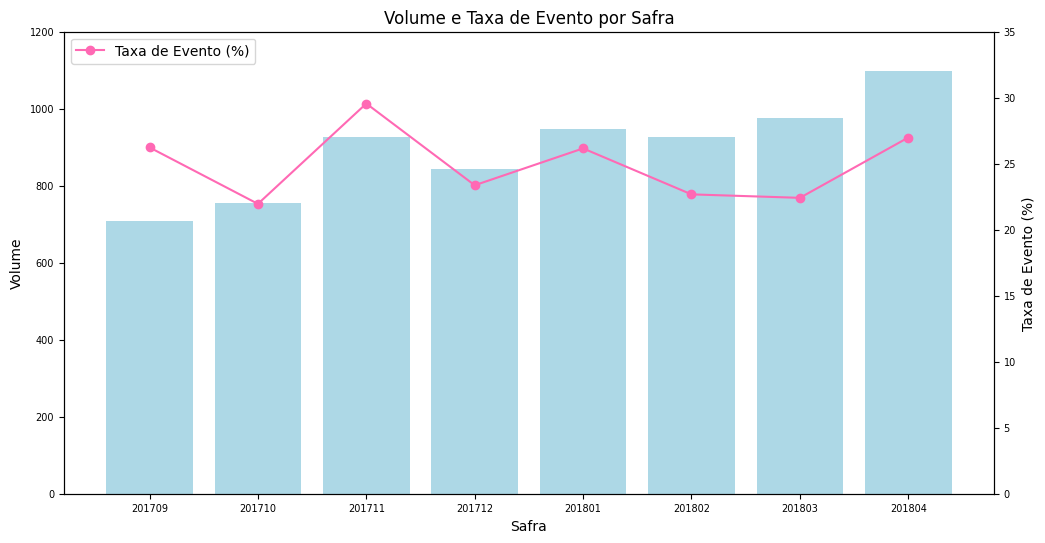

In [50]:
df_tx_evento = plot_tx_event_volume_safra(abt_treino_01,
                                              target='churn_flag',
                                              safra='safra',
                                              ymax_volume=1200, ymax_taxa_evento=35)

In [51]:
# Calcular a média do FPD e o volume por AAAAMM
resultado_teste = abt_teste_01.groupby('safra').agg({'churn_flag': 'mean', 'safra': 'count'}).rename(columns={'safra': 'Volume'}).reset_index()
resultado_teste.columns = ['Safra (AAAA)', 'Taxa_de_Evento', 'Volume']

# Exiba a tabela
resultado_teste

,Safra (AAAA),Taxa_de_Evento,Volume
0,201805,0.281421,1098
1,201806,0.269731,1153


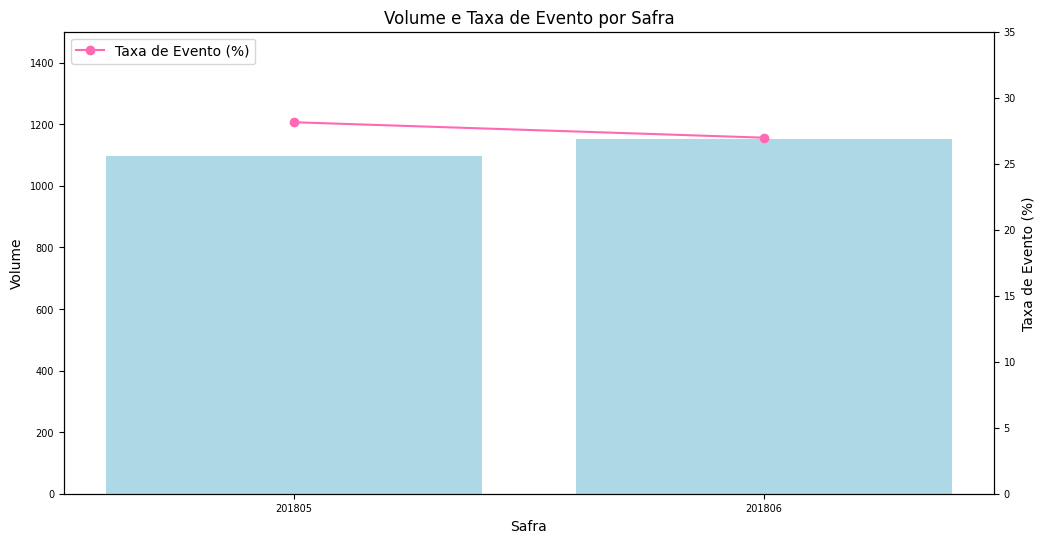

In [52]:
df_tx_evento_teste = plot_tx_event_volume_safra(abt_teste_01,
                                              target='churn_flag',
                                              safra='safra',
                                              ymax_volume=1500, ymax_taxa_evento=35)

In [53]:
metadados = generate_metadata(abt_treino_01, ids=['seller_id', 'safra'], targets=['churn_flag'], orderby='PC_NULOS')
metadados.head(10)

,FEATURE,USO_FEATURE,QT_NULOS,PC_NULOS,CARDINALIDADE,TIPO_FEATURE
0,raz_med_u9m_u12m_pctPedidosMaiorProduto_pedidos,Explicativa,7183,100.00,0,float64
1,raz_med_u1m_u3m_pctPedidosMaiorProduto_pedidos,Explicativa,7183,100.00,0,float64
2,raz_med_u3m_u6m_pctPedidosMaiorProduto_pedidos,Explicativa,7183,100.00,0,float64
3,raz_med_u6m_u9m_pctPedidosMaiorProduto_pedidos,Explicativa,7183,100.00,0,float64
4,raz_med_u1m_u3m_pctPedidoCancelado_pedidos,Explicativa,6782,94.42,28,float64
5,raz_med_u3m_u6m_pctPedidoCancelado_pedidos,Explicativa,6662,92.75,45,float64
6,raz_med_u6m_u9m_pctPedidoCancelado_pedidos,Explicativa,6582,91.63,36,float64
7,raz_med_u9m_u12m_pctPedidoCancelado_pedidos,Explicativa,6562,91.35,20,float64
8,raz_med_u1m_u3m_pct_review_2_reviews,Explicativa,5048,70.28,127,float64
9,raz_med_u1m_u3m_qtd_review_2_reviews,Explicativa,5041,70.18,72,float64


In [54]:
cols_high_null = abt_treino_01.columns[
    abt_treino_01.isnull().mean() >= 0.70
].tolist()

cols_drop = [
    'seller_id',
    'safra',
    'churn_flag'
]

cols_drop_total = list(set(cols_drop + cols_high_null))
# Treino
X_train = abt_treino_01.drop(columns=cols_drop_total)
y_train = abt_treino_01['churn_flag']

# Teste
X_test = abt_teste_01.drop(columns=cols_drop_total)
y_test = abt_teste_01['churn_flag']

In [55]:
metadados = generate_metadata(X_train, ids=['seller_id', 'safra'], targets=['churn_flag'], orderby='PC_NULOS')
metadados.head(10)

,FEATURE,USO_FEATURE,QT_NULOS,PC_NULOS,CARDINALIDADE,TIPO_FEATURE
0,raz_med_u1m_u3m_pct_negativas_com_atraso_reviews,Explicativa,4750,66.13,354,float64
1,raz_med_u3m_u6m_pct_review_2_reviews,Explicativa,4629,64.44,134,float64
2,raz_med_u3m_u6m_qtd_review_2_reviews,Explicativa,4617,64.28,156,float64
3,raz_med_u1m_u3m_flag_review_media_baixa_reviews,Explicativa,4540,63.20,9,float64
4,raz_med_u1m_u3m_qtd_negativas_com_atraso_reviews,Explicativa,4457,62.05,133,float64
5,raz_med_u6m_u9m_pct_review_2_reviews,Explicativa,4440,61.81,101,float64
6,raz_med_u6m_u9m_qtd_review_2_reviews,Explicativa,4423,61.58,214,float64
7,raz_med_u9m_u12m_pct_review_2_reviews,Explicativa,4382,61.01,62,float64
8,raz_med_u9m_u12m_qtd_review_2_reviews,Explicativa,4359,60.68,186,float64
9,raz_med_u3m_u6m_pct_negativas_com_atraso_reviews,Explicativa,4281,59.60,439,float64


In [56]:
cat_features_low_card = metadados[(metadados['TIPO_FEATURE'] == 'object') & 
                                (metadados['CARDINALIDADE'] < 20)]['FEATURE'].tolist()

cat_features_high_card = metadados[(metadados['TIPO_FEATURE'] == 'object') & 
                                 (metadados['CARDINALIDADE'] >= 20)]['FEATURE'].tolist()

num_features = metadados[(metadados['TIPO_FEATURE'] != 'object')]['FEATURE'].tolist()

# Definir pipelines separados para cada tipo de feature categórica
cat_pipe_low = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

cat_pipe_high = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_enc', TargetEncoder())
])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Combinar todos os pipelines
preprocessor = ColumnTransformer([
    ('cat_low', cat_pipe_low, cat_features_low_card),
    ('cat_high', cat_pipe_high, cat_features_high_card),
    ('num', num_pipe, num_features)
])

preprocesssor = Pipeline(steps=[("preprocessor", preprocessor)])

# Aplicar o pré-processamento
X_train_processed = preprocesssor.fit_transform(X_train, y_train)
X_test_processed = preprocesssor.transform(X_test)

# Para obter os nomes das colunas após o OneHotEncoder
# (isso é mais complexo pois o OneHotEncoder cria múltiplas colunas)
onehot_columns = []
if len(cat_features_low_card) > 0:
    onehot = preprocesssor.named_steps['preprocessor'].named_transformers_['cat_low'].named_steps['onehot']
    for i, col in enumerate(cat_features_low_card):
        cats = onehot.categories_[i]
        onehot_columns.extend([f"{col}_{cat}" for cat in cats])

# Nomes finais das colunas
processed_columns = onehot_columns + cat_features_high_card + num_features

print("Colunas geradas:", X_train_processed.shape[1])
print("Nomes criados:", len(processed_columns))

print("OneHot:", len(onehot_columns))
print("High card:", len(cat_features_high_card))
print("Num:", len(num_features))

# Converter para DataFrame
X_train_processed = pd.DataFrame(X_train_processed, columns=processed_columns)
X_test_processed = pd.DataFrame(X_test_processed, columns=processed_columns)


Colunas geradas: 1187
Nomes criados: 1187
OneHot: 0
High card: 0
Num: 1187


In [57]:
import os
os.makedirs('../scripts/artifacts/', exist_ok=True)
with open('../scripts/artifacts/prd_preprocesssor_skl.pkl', 'wb') as f:
  pickle.dump(preprocesssor, f)

In [58]:
clf = RandomForestClassifier(random_state=0, max_depth=5, min_samples_leaf=2)
clf.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

Número de features selecionadas:  23


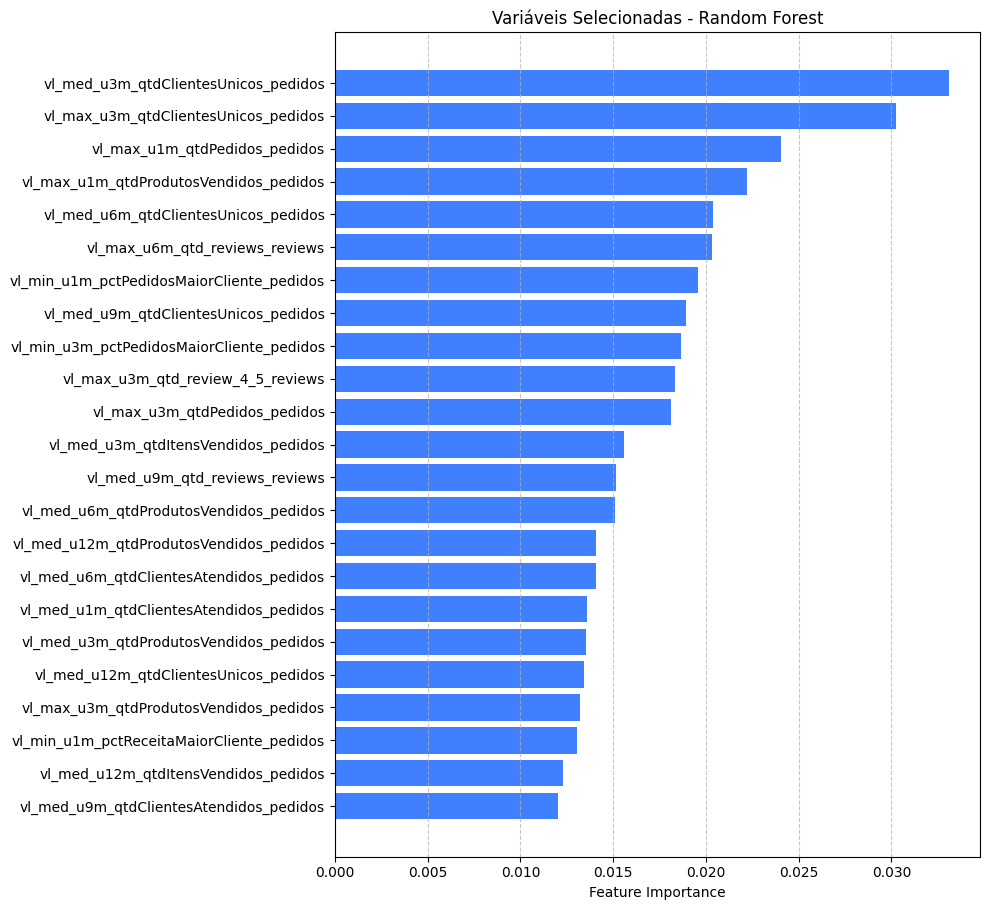

In [59]:
#Obtendo o feature importance
feature_importances = clf.feature_importances_
features = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Importance': feature_importances
})

#Ordenar vars por importância
features = features.sort_values(by='Importance', ascending=False)

#Estabelecendo um ponto de corte
cutoff_maximp = 0.35

cutoff = cutoff_maximp * feature_importances.max()

# Selecionando vars acima do ponto de corte
selected_features = X_train_processed.columns[feature_importances > cutoff].tolist()
print('Número de features selecionadas: ', len(selected_features))

#Ordenar vars por importância
features = features.sort_values(by='Importance', ascending=True)

# Filtrar o DataFrame para apenas as features acima do corte
selected_features_df = features[features['Importance'] > cutoff]

# Ajusta o tamanho da figura com base no número de features selecionadas
plt.figure(figsize=(10, len(selected_features_df)*0.4))

# Plota as features selecionadas
plt.barh(selected_features_df['Feature'], selected_features_df['Importance'], color=(0.25, 0.5, 1))
plt.xlabel("Feature Importance")
plt.title("Variáveis Selecionadas - Random Forest")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [60]:
import os
os.makedirs('../scripts/artifacts/', exist_ok=True)
# Salva as features selecionadas na pasta artifacts
with open('../scripts/artifacts/prd_selected_features_skl.pkl', 'wb') as f:
  pickle.dump(selected_features, f)

In [61]:
algoritmos = [
    DecisionTreeClassifier(criterion='gini', random_state=0, max_depth=7, min_samples_leaf=3),
    RandomForestClassifier(random_state=0, max_depth=7, min_samples_leaf=3),
    LGBMClassifier(random_state=0, max_depth=7, min_child_samples=3, n_jobs=-1, verbosity=-1,)
]

for algoritmo in algoritmos:

    nome_algoritmo = str(algoritmo)[:str(algoritmo).find("(")]
    # Treino do modelo
    algoritmo.fit(X_train_processed[selected_features],y_train)

    # Avaliar modelo
    metricas = calculate_metrics_models_classifier(nome_algoritmo,algoritmo, X_train_processed[selected_features], y_train, X_test_processed[selected_features], y_test)
    display(metricas)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,DecisionTreeClassifier,Treino,0.790199,0.602994,0.471047,0.823142,0.646284,0.514053
1,DecisionTreeClassifier,Teste,0.734785,0.523810,0.408065,0.749887,0.499774,0.396682


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,RandomForestClassifier,Treino,0.790617,0.609281,0.453229,0.834216,0.668432,0.523523
1,RandomForestClassifier,Teste,0.745446,0.552573,0.398387,0.764733,0.529466,0.410017


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,LGBMClassifier,Treino,0.822498,0.668827,0.574610,0.898940,0.797881,0.664017
1,LGBMClassifier,Teste,0.740116,0.536534,0.414516,0.753983,0.507966,0.384708


In [62]:
import optuna

OPTUNA_EARLY_STOPING = 20

class EarlyStoppingExceeded(optuna.exceptions.OptunaError):
    early_stop = OPTUNA_EARLY_STOPING
    early_stop_count = 0
    best_score = None

def early_stopping_opt(study, trial):
    if EarlyStoppingExceeded.best_score == None:
      EarlyStoppingExceeded.best_score = study.best_value

    if study.best_value < EarlyStoppingExceeded.best_score:
        EarlyStoppingExceeded.best_score = study.best_value
        EarlyStoppingExceeded.early_stop_count = 0
    else:
      if EarlyStoppingExceeded.early_stop_count > EarlyStoppingExceeded.early_stop:
            EarlyStoppingExceeded.early_stop_count = 0
            best_score = None
            raise EarlyStoppingExceeded()
      else:
            EarlyStoppingExceeded.early_stop_count=EarlyStoppingExceeded.early_stop_count+1
    #print(f'EarlyStop counter: {EarlyStoppingExceeded.early_stop_count}, Best score: {study.best_value} and {EarlyStoppingExceeded.best_score}')
    return


In [63]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fbeta_scorer = make_scorer(
        fbeta_score,
        beta=1.3,          # dá mais peso para recall
        pos_label=1      # classe FPD
)


# Objetiva do Optuna
def objective(trial):


    # 1. DEFINIÇÃO DO ESPAÇO DE BUSCA DE HIPERPARÂMETROS
    # Cada trial do Optuna irá sortear uma combinação diferente

    params = {

        # Hiperparâmetros básicos
        'n_estimators': trial.suggest_int('n_estimators', 5, 50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        
        # Regularização
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        
        # Amostragem
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        
        # Balanceamento de classes
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 2, 10),
        
        # Tipo de boosting

        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 30),
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt']),
        'objective': 'binary',
        'verbosity': -1,
        'random_state': 42
    }


    model = LGBMClassifier(**params)


    # cross_val_score retorna uma lista com a métrica para cada fold
    scores = cross_val_score(model, X_train_processed[selected_features], y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    # Média dos AUCs
    return np.mean(scores)

# Estudo
study = optuna.create_study(direction="maximize",study_name="modelo")
study.add_trials(study.trials)
try:
    study.optimize(objective, n_trials=100, timeout=600, callbacks=[early_stopping_opt])

except EarlyStoppingExceeded:
    print(f'EarlyStopping Exceeded: No new best scores on iters {OPTUNA_EARLY_STOPING}')

print("Number of finished trials: {}".format(len(study.trials)))

print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2026-06-21 17:05:13,428] A new study created in memory with name: modelo
[I 2026-06-21 17:05:15,793] Trial 0 finished with value: 0.7832030664022052 and parameters: {'n_estimators': 39, 'learning_rate': 0.19217394599734416, 'max_depth': 10, 'num_leaves': 43, 'reg_alpha': 0.502181157501616, 'reg_lambda': 0.6551549523899364, 'subsample': 0.6607675069108457, 'colsample_bytree': 0.6742098780700749, 'scale_pos_weight': 6.863271758711969, 'boosting_type': 'gbdt'}. Best is trial 0 with value: 0.7832030664022052.
[I 2026-06-21 17:05:17,944] Trial 1 finished with value: 0.786989244161791 and parameters: {'n_estimators': 14, 'learning_rate': 0.027499708206468066, 'max_depth': 7, 'num_leaves': 62, 'reg_alpha': 0.9311962883991158, 'reg_lambda': 0.5367452237816132, 'subsample': 0.9548980217474902, 'colsample_bytree': 0.7963560505242482, 'scale_pos_weight': 4.982571533503458, 'boosting_type': 'gbdt'}. Best is trial 1 with value: 0.786989244161791.
[I 2026-06-21 17:05:19,256] Trial 2 finished with

EarlyStopping Exceeded: No new best scores on iters 20
Number of finished trials: 22
Best trial:
  Value: 0.7919111915587983
  Params: 
    n_estimators: 22
    learning_rate: 0.0449667817311152
    max_depth: 3
    num_leaves: 98
    reg_alpha: 0.8309706404135109
    reg_lambda: 0.7188407542868336
    subsample: 0.5991907698470211
    colsample_bytree: 0.5948034735847352
    scale_pos_weight: 4.343413270633825
    boosting_type: gbdt


In [64]:
algoritmo = LGBMClassifier(**study.best_params, verbosity=-1)

tuned_model = TunedThresholdClassifierCV(
    estimator=algoritmo,
    scoring="roc_auc",
    cv=5
)

tuned_model.fit(X_train_processed[selected_features], y_train)

metricas = calculate_metrics_models_classifier(
    "LGBM_TunedThreshold",
    tuned_model,
    X_train_processed[selected_features],
    y_train,
    X_test_processed[selected_features],
    y_test
)

display(metricas)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,LGBM_TunedThreshold,Treino,0.677990,0.426079,0.829621,0.798411,0.596822,0.467277
1,LGBM_TunedThreshold,Teste,0.659263,0.436142,0.809677,0.769307,0.538615,0.415695


In [65]:
tuned_model.best_threshold_

0.4468166010079674

In [66]:
import os
os.makedirs('../scripts/artifacts/', exist_ok=True)
with open('../scripts/artifacts/modelo_lgbm.pkl', 'wb') as file:
  pickle.dump(tuned_model, file)

In [77]:
y_train.index = X_train_processed.index

bins = 6
tab = pd.concat([X_train_processed[selected_features],y_train],axis=1).copy()
tab['score'] = tuned_model.predict_proba(tab.drop(columns=['churn_flag']))[:,0]
tab['decile'] = pd.qcut(tab['score'], bins, labels=False)

# Criar tabela detalhada
table = tab.groupby('decile').agg(
    min_score=pd.NamedAgg(column='score', aggfunc='min'),
    max_score=pd.NamedAgg(column='score', aggfunc='max'),
    event_rate=pd.NamedAgg(column='churn_flag', aggfunc='mean'),
    volume=pd.NamedAgg(column='churn_flag', aggfunc='size'),
    qt_bads=pd.NamedAgg(column='churn_flag', aggfunc=lambda x: (x == 1).sum()),
    perc_total_bads=pd.NamedAgg(column='churn_flag', aggfunc=lambda x: (x == 1).sum()/tab[tab.churn_flag == 1].shape[0])
).reset_index()
table['min_score'] = 1000*table['min_score']
table['max_score'] = 1000*table['max_score']
table_train = table[['decile','event_rate','perc_total_bads', 'volume']]
table_train.rename(columns={'event_rate':'event_rate_train','perc_total_bads':'perc_total_bads_train', 'volume': 'volume_train'},inplace=True)
table_train

,decile,event_rate_train,perc_total_bads_train,volume_train
0,0,0.570603,0.384744,1211
1,1,0.386901,0.319042,1481
2,2,0.266112,0.142539,962
3,3,0.157570,0.099666,1136
4,4,0.059856,0.041759,1253
5,5,0.019298,0.012249,1140


In [78]:
y_test.index = X_test_processed.index

bins = 6
tab = pd.concat([X_test_processed[selected_features],y_test],axis=1).copy()
tab['score'] = tuned_model.predict_proba(tab.drop(columns=['churn_flag']))[:,0]
tab['decile'] = pd.qcut(tab['score'], bins, labels=False)

# Criar tabela detalhada
table = tab.groupby('decile').agg(
    min_score=pd.NamedAgg(column='score', aggfunc='min'),
    max_score=pd.NamedAgg(column='score', aggfunc='max'),
    event_rate=pd.NamedAgg(column='churn_flag', aggfunc='mean'),
    volume=pd.NamedAgg(column='churn_flag', aggfunc='size'),
    qt_bads=pd.NamedAgg(column='churn_flag', aggfunc=lambda x: (x == 1).sum()),
    perc_total_bads=pd.NamedAgg(column='churn_flag', aggfunc=lambda x: (x == 1).sum()/tab[tab.churn_flag == 1].shape[0])
).reset_index()
table['min_score'] = 1000*table['min_score']
table['max_score'] = 1000*table['max_score']
table_test = table[['decile','event_rate','perc_total_bads', 'volume']]
table_test.rename(columns={'event_rate':'event_rate_test','perc_total_bads':'perc_total_bads_test', 'volume':'volume_test'},inplace=True)
table_test

,decile,event_rate_test,perc_total_bads_test,volume_test
0,0,0.560209,0.345161,382
1,1,0.417391,0.309677,460
2,2,0.307692,0.148387,299
3,3,0.193906,0.112903,361
4,4,0.120603,0.077419,398
5,5,0.011396,0.006452,351


In [79]:
summary = pd.merge(table_train,table_test,on='decile',how='inner')
summary

,decile,event_rate_train,perc_total_bads_train,volume_train,event_rate_test,perc_total_bads_test,volume_test
0,0,0.570603,0.384744,1211,0.560209,0.345161,382
1,1,0.386901,0.319042,1481,0.417391,0.309677,460
2,2,0.266112,0.142539,962,0.307692,0.148387,299
3,3,0.157570,0.099666,1136,0.193906,0.112903,361
4,4,0.059856,0.041759,1253,0.120603,0.077419,398
5,5,0.019298,0.012249,1140,0.011396,0.006452,351


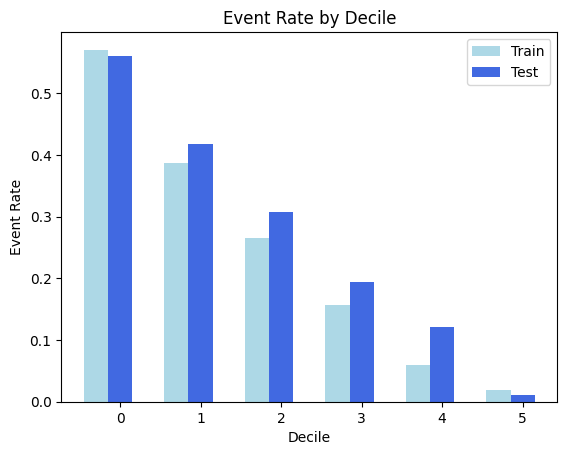

In [80]:
# Plotando o gráfico de barras para Event Rate por Decil
barWidth = 0.3
r1 = np.arange(len(summary))
r2 = [x + barWidth for x in r1]

plt.bar(r1, summary['event_rate_train'], color='lightblue', width=barWidth, label='Train')
plt.bar(r2, summary['event_rate_test'], color='royalblue', width=barWidth, label='Test')

plt.xlabel('Decile')
plt.ylabel('Event Rate')
plt.title('Event Rate by Decile')
plt.xticks([r + barWidth for r in range(len(summary))], summary['decile'])
plt.legend()
plt.show()

In [71]:
import numpy as np
from sklearn.metrics import roc_curve

def calcular_ks(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    return np.max(tpr - fpr)
    
# Converter safra para string
abt_treino["safra"] = abt_treino["safra"].astype(str)
abt_teste["safra"] = abt_teste["safra"].astype(str)

# Gerar score
abt_treino["score"] = tuned_model.predict_proba(
    X_train_processed[selected_features]
)[:, 1]

abt_teste["score"] = tuned_model.predict_proba(
    X_test_processed[selected_features]
)[:, 1]


# KS por safra - Treino
ks_treino = (
    abt_treino
    .groupby("safra")
    .apply(lambda x: calcular_ks(x["churn_flag"], x["score"]))
    .reset_index(name="KS_TREINO")
)

# KS por safra - Teste
ks_teste = (
    abt_teste
    .groupby("safra")
    .apply(lambda x: calcular_ks(x["churn_flag"], x["score"]))
    .reset_index(name="KS_TESTE")
)
# Merge agora funciona
ks_por_safra = ks_treino.merge(ks_teste, on="safra", how="outer")
ks_por_safra = ks_por_safra.sort_values("safra")

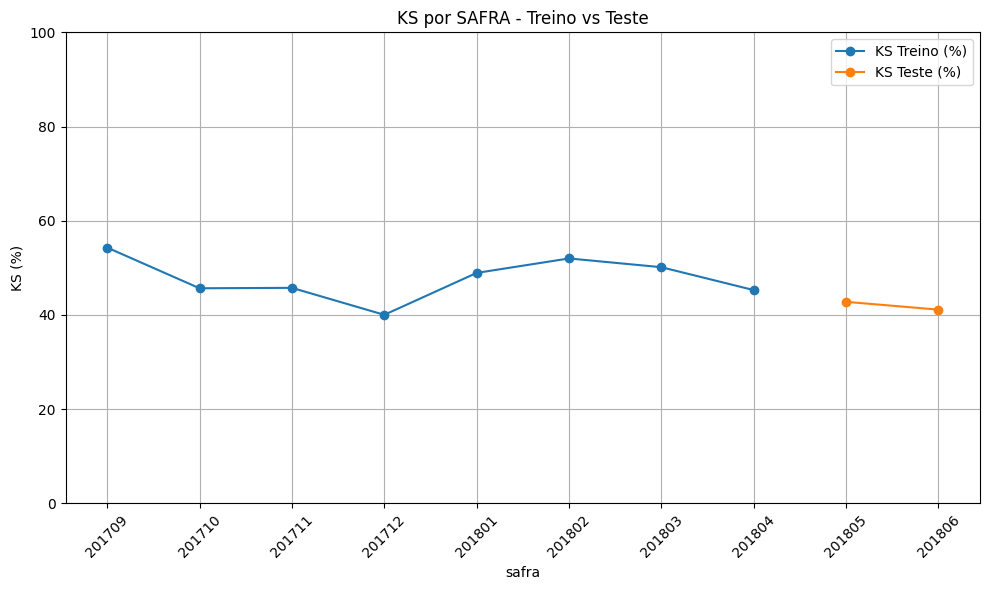

In [72]:
plt.figure(figsize=(10,6))

# Multiplicar por 100 para escala percentual
plt.plot(ks_por_safra["safra"], ks_por_safra["KS_TREINO"] * 100, marker="o", label="KS Treino (%)")
plt.plot(ks_por_safra["safra"], ks_por_safra["KS_TESTE"] * 100, marker="o", label="KS Teste (%)")

plt.xlabel("safra")
plt.ylabel("KS (%)")              # agora em %
plt.title("KS por SAFRA - Treino vs Teste")

plt.ylim(0, 100)                  # força eixo Y de 0 a 100
plt.xticks(rotation=45)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()